In [1]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from amplitude import get_amplitude_interpolant
from trajectory import get_trajectory_generator

/Users/c.chapman-bird@bham.ac.uk/miniconda3/envs/few-generic-redo/lib/python3.12/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.1.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.0
  warnings.warn(


In [2]:
traj_gen = get_trajectory_generator("./high-ecc-schw/fluxes.h5")
amp_interp, psi_r, delta_psi_r = get_amplitude_interpolant(
    "./high-ecc-schw/amplitude_mag_phase.h5",
    interp_type='real-imag'
)
amp_interp = jax.vmap(amp_interp, in_axes=(0, 0))

amp_interp_mag_phase, psi_r, delta_psi_r = get_amplitude_interpolant(
    "./high-ecc-schw/amplitude_mag_phase.h5",
    interp_type='mag-phase'
)
amp_interp_mag_phase = jax.vmap(amp_interp_mag_phase, in_axes=(0, 0))

n_modes = 256
amp_interp_fourier, psi_r, delta_psi_r = get_amplitude_interpolant(
    "./high-ecc-schw/amplitude_mag_phase.h5",
    interp_type='fourier',
    n_fourier_modes = n_modes
)

amp_interp_fourier = jax.vmap(amp_interp_fourier, in_axes=(0, 0))

In [102]:
p_test = jnp.linspace(8.0, 12, 1001)
e_test = jnp.full_like(p_test, 0.99)
re_im_test = amp_interp(p_test, e_test)
mag_phase_test = amp_interp_mag_phase(p_test, e_test)
mag_phase_from_re_im = (
    jnp.sqrt(re_im_test[0]**2 + re_im_test[1]**2),
    - jnp.unwrap(jnp.arctan2(re_im_test[1], re_im_test[0]), axis=-1)
)
p_test - 6 - 2*e_test

Array([0.02 , 0.024, 0.028, ..., 4.012, 4.016, 4.02 ], dtype=float64)

In [3]:
from waveform import get_radial_waveform_generator, get_radial_fourier_waveform_generator

In [4]:
wave_gen = get_radial_waveform_generator(
    traj_gen,
    amp_interp,
    delta_psi_r,
    psi_r.size,
    amp_type='real-imag'
)

wave_gen_mag_phase = get_radial_waveform_generator(
    traj_gen,
    amp_interp_mag_phase,
    delta_psi_r,
    psi_r.size,
    amp_type='mag-phase'
)

wave_gen_fourier = get_radial_fourier_waveform_generator(
    traj_gen,
    amp_interp_fourier,
    n_modes,
)

In [5]:
m1 = 1e5
m2 = 1e1
p0 = 9.0
e0 = 0.999

In [6]:
dt = 1
N = int(1e7)

t_eval = jnp.arange(N) * dt
T = t_eval[-1] / 3.154e7

waveform = wave_gen(
    t_eval,
    m1,
    m2,
    p0,
    e0,
    0.0,
    -0.005,
    jnp.pi/3,
    1.0,
    T,
)

waveform_mag_phase = wave_gen_mag_phase(
    t_eval,
    m1,
    m2,
    p0,
    e0,
    0.0,
    -0.005,
    jnp.pi/3,
    1.0,
    T,
)

waveform_fourier = wave_gen_fourier(
    t_eval,
    m1,
    m2,
    p0,
    e0,
    0.0,
    -0.005,
    jnp.pi/3,
    1.0,
    T,
)

if jnp.any(jnp.isnan(waveform)):
    last_point = jnp.where(jnp.isnan(waveform))[0][0]
else:
    last_point = waveform.size

waveform = waveform[:last_point]
waveform_mag_phase = waveform_mag_phase[:last_point]
waveform_fourier = waveform_fourier[:last_point]
t_eval = t_eval[:last_point]

In [7]:
# wave_gen_jit= jax.jit(wave_gen)
# def foo():
#     waveform = wave_gen_jit(
#         t_eval,
#         m1,
#         m2,
#         p0,
#         e0,
#         0.0,
#         -0.004,
#         jnp.pi/3,
#         1.0,
#         T,
#     )
#     return waveform

# _ = foo()

In [8]:
# %timeit foo()

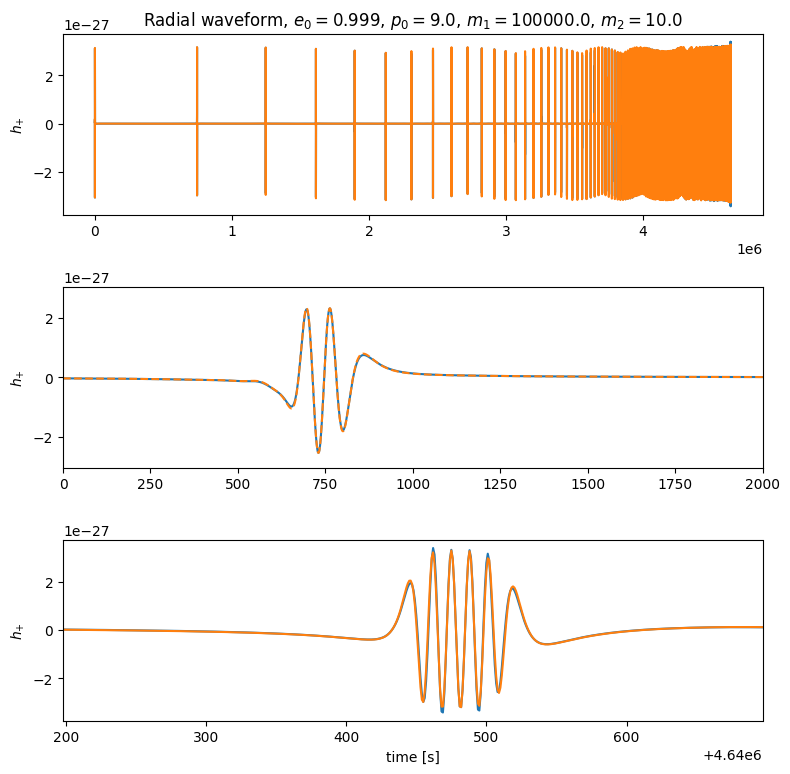

In [9]:
plt.figure(figsize=(8, 8))
plt.subplot(311)
plt.plot(t_eval, waveform.real)
plt.plot(t_eval, waveform_mag_phase. real)
# plt.plot(t_eval, waveform_fourier.real)
# plt.plot(t_eval,waveform.real -  waveform_fourier.real)
plt.ylabel(r"$h_{\plus}$")
plt.title(rf"Radial waveform, $e_0 = {e0}$, $p_0 = {p0}$, $m_1 = {m1}$, $m_2 = {m2}$")

plt.subplot(312)
plt.plot(t_eval, waveform.imag)
plt.plot(t_eval, waveform_mag_phase.imag, ls='--')
# plt.plot(t_eval, waveform_fourier.real)
plt.xlim(0, t_eval[2000])
plt.ylabel(r"$h_{\plus}$")
plt.subplot(313)
plt.plot(t_eval, waveform.real)
plt.plot(t_eval, waveform_mag_phase.real)
# plt.plot(t_eval, waveform_fourier.real)
# plt.plot(t_eval, waveform_fourier.real)
plt.xlim(t_eval[last_point-500], t_eval[last_point-1])
# plt.plot(t_eval, waveform.imag)
# plt.xlim(0, 600000)
plt.xlabel("time [s]")
plt.ylabel(r"$h_{\plus}$")
plt.tight_layout()


In [10]:
def mism(a, b):
    a_f_r = jnp.fft.rfft(a.real)
    b_f_r = jnp.fft.rfft(b.real)
    
    a_f_im = jnp.fft.rfft(a.imag)
    b_f_im = jnp.fft.rfft(b.imag)
    
    a_b = (a_f_r * b_f_r.conj()).real.sum() + (a_f_im * b_f_im.conj()).real.sum()
    a_a = (a_f_r * a_f_r.conj()).real.sum() + (a_f_im * a_f_im.conj()).real.sum()
    b_b = (b_f_r * b_f_r.conj()).real.sum() + (b_f_im * b_f_im.conj()).real.sum()
    return 1 - a_b / jnp.sqrt(a_a * b_b)


mism(waveform, waveform_mag_phase), mism(waveform, waveform_fourier), mism(waveform_mag_phase, waveform_fourier)

(Array(0.78237947, dtype=float64),
 Array(1.90796815e-08, dtype=float64),
 Array(0.78237959, dtype=float64))

In [50]:
# (Array(0.00709279, dtype=float64),
#  Array(0.00025824, dtype=float64),
#  Array(0.00725092, dtype=float64))

Text(0, 0.5, '$h_{\\plus}$')

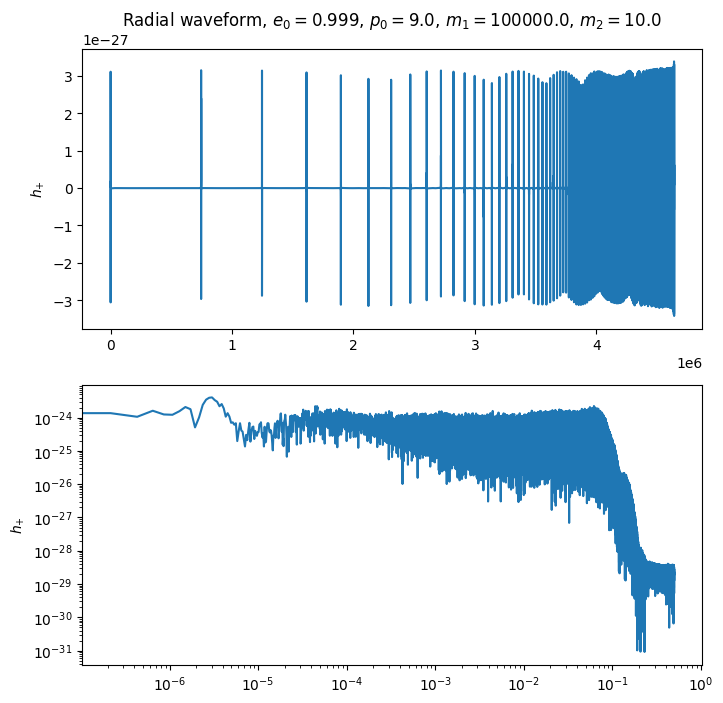

In [10]:
wave_f = jnp.fft.rfft(waveform.real[:last_point])
frs = jnp.fft.rfftfreq(last_point, dt)
plt.figure(figsize=(8, 8))
plt.subplot(211)
plt.plot(t_eval, waveform.real)
plt.ylabel(r"$h_{\plus}$")
plt.title(rf"Radial waveform, $e_0 = {e0}$, $p_0 = {p0}$, $m_1 = {m1}$, $m_2 = {m2}$")

plt.subplot(212)
plt.loglog(frs, jnp.abs(wave_f))
plt.ylabel(r"$h_{\plus}$")


In [11]:
t_trim = t_eval[:last_point]
wave_trim = waveform.real[:last_point]
dT = 86400 / 4
nT = int(t_trim[-1] / dT)
dt = 1
points_per_seg = int(dT / dt)

cut_point = int(nT * dT / dt)
t_trim = t_trim[:cut_point]
wave_trim = wave_trim[:cut_point]

frseg = jnp.fft.rfftfreq(points_per_seg, dt)
tseg = jnp.arange(nT) * dT

# time-frequency
wave_tf = jnp.fft.rfft(wave_trim.reshape(nT, points_per_seg), axis=1)

(0.0001, 0.1)

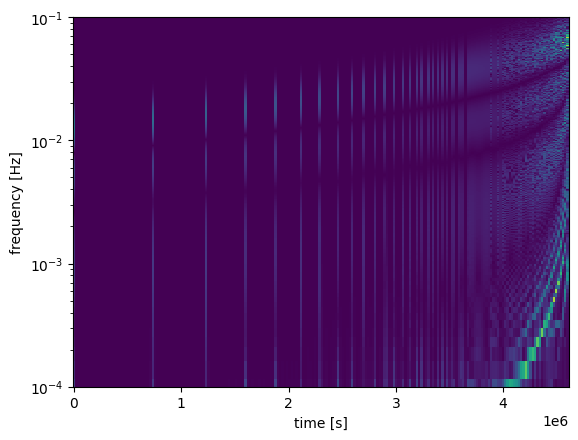

In [12]:
plt.pcolormesh(tseg, frseg, jnp.abs(wave_tf.T), shading='auto')
plt.yscale('log')
plt.xlabel("time [s]")
plt.ylabel("frequency [Hz]")
plt.ylim(1e-4, 1e-1)

In [13]:
m1 = 1e5
m2 = 1e2
p0 = 9.0
e0 = 0.99999

dt = 1
N = int(1e7)

t_eval = jnp.arange(N) * dt
T = t_eval[-1] / 3.154e7

waveform = wave_gen(
    t_eval,
    m1,
    m2,
    p0,
    e0,
    0.0,
    -1e-5,
    jnp.pi/3,
    1.0,
    T,
)

if jnp.any(jnp.isnan(waveform)):
    last_point = jnp.where(jnp.isnan(waveform))[0][0]
else:
    last_point = waveform.size

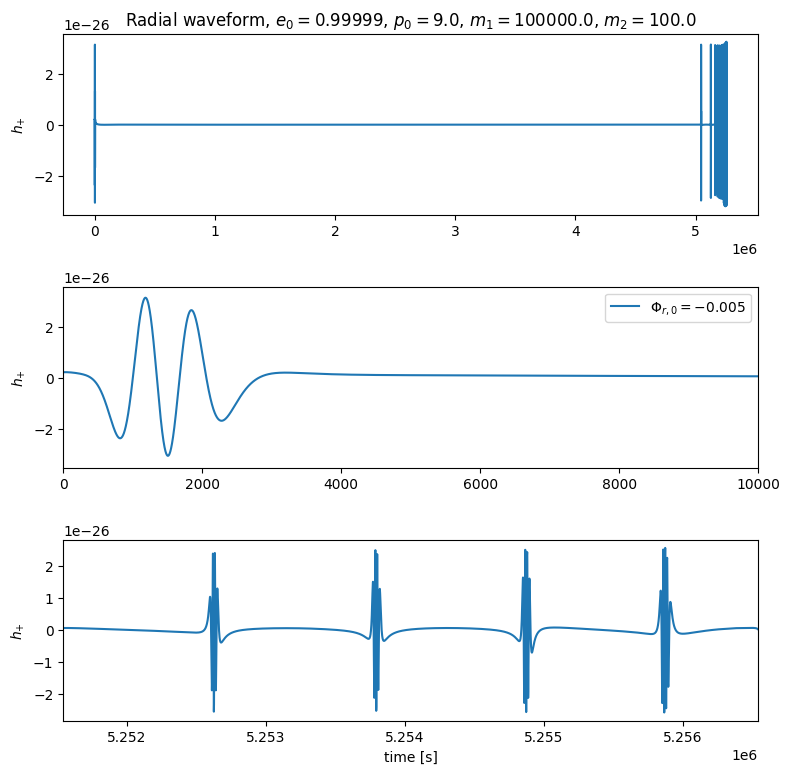

In [14]:
plt.figure(figsize=(8, 8))
plt.subplot(311)
plt.plot(t_eval, waveform.real)
plt.ylabel(r"$h_{\plus}$")
plt.title(rf"Radial waveform, $e_0 = {e0}$, $p_0 = {p0}$, $m_1 = {m1}$, $m_2 = {m2}$")

plt.subplot(312)
plt.plot(t_eval, waveform.real, label=r"$\Phi_{r,0} = -0.005$")
plt.legend()
plt.xlim(0, t_eval[10000])
plt.ylabel(r"$h_{\plus}$")
plt.subplot(313)
plt.plot(t_eval, waveform.imag)
plt.xlim(t_eval[last_point-5000], t_eval[last_point-1])
# plt.plot(t_eval, waveform.imag)
# plt.xlim(0, 600000)
plt.xlabel("time [s]")
plt.ylabel(r"$h_{\plus}$")
plt.tight_layout()
